# Download Training Data

In [1]:
import requests, zipfile, io
import pandas as pd

# kaggle does not allow direct download anymore since feb 2025
# url = 'https://www.kaggle.com/api/v1/datasets/download/prishasawhney/mushroom-dataset?datasetVersionNumber=1'
url = 'http://fsck.ch/archive.zip'  # alternative download url
r = requests.get(url)

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    with z.open('mushroom_cleaned.csv') as f:
        df = pd.read_csv(f)

df.head()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


# Create bucket traindata in the object store. 

In [2]:
import s3fs

# create a reference to the object store
s3 = s3fs.S3FileSystem()

# create a bucket
try:
    s3.mkdir("traindata")
except FileExistsError:
    print("Bucket already exists")

df.to_parquet('s3://traindata/train_raw.parquet', storage_options={"anon": False})

# some more commands
s3.ls('traindata')
s3.du('traindata/train_raw.parquet')

308282

## Read Training Data from Object Store

In [3]:
df = pd.read_parquet('s3://traindata/train_raw.parquet', storage_options={"anon": False})

In [4]:
# Exploratory Data Analysis
df.head()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


# Exploratory Data Analysis

In [6]:
df.shape

(54035, 9)

In [7]:
df.dtypes

cap-diameter         int64
cap-shape            int64
gill-attachment      int64
gill-color           int64
stem-height        float64
stem-width           int64
stem-color           int64
season             float64
class                int64
dtype: object

In [8]:
df.nunique()

cap-diameter       1847
cap-shape             7
gill-attachment       7
gill-color           12
stem-height        1455
stem-width         3510
stem-color           13
season                4
class                 2
dtype: int64

In [10]:
df['class'].value_counts()

class
1    29675
0    24360
Name: count, dtype: int64

# Feature Types

In [11]:
categoricals = ['cap-shape', 'gill-attachment', 'gill-color', 'stem-color']
numericals = [c for c in df.drop('class', axis='columns').columns if c not in categoricals]

In [14]:
# Convert to float for MLFlow
for col in df.columns:
    df[col] = df[col].astype('float')
df.dtypes

cap-diameter       float64
cap-shape          float64
gill-attachment    float64
gill-color         float64
stem-height        float64
stem-width         float64
stem-color         float64
season             float64
class              float64
dtype: object

# Prepare Final Test Set

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('class', axis='columns'), df['class'], random_state=42)

# simple model with sklearn

In [18]:
# A good first model is often a Gradient Boosting Classifier, since it often yields good results and does not require scaling or one-hot encoding.
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(n_estimators=10)  # 10 is a bit small, but it will speed up our training and validation

# Evaluate Model

In [19]:
from sklearn.model_selection import cross_val_score

n_folds = 10
scores = cross_val_score(clf, X_train, y_train, cv=n_folds)

print(f"Our classifier has an accuracy of {scores.mean():0.2f}", end=" ")
print(f"(standard deviation {scores.std():0.2f}) over all {n_folds} folds")

Our classifier has an accuracy of 0.73 (standard deviation 0.01) over all 10 folds


# Check Final Score
At the end we check our model against the test set to evaluate the score (because in long modeling phases it can happen that we overfit the validation set). 

Our classifier has an accuracy of 0.73


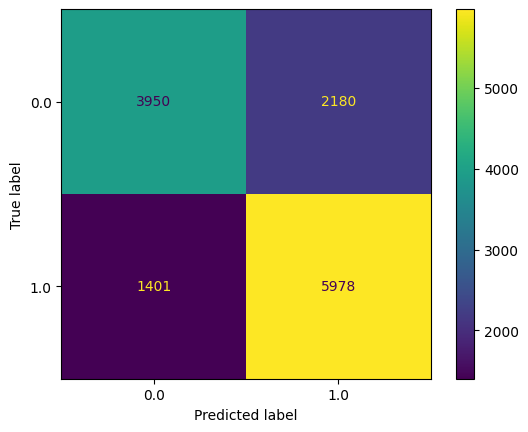

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

print(f"Our classifier has an accuracy of {accuracy_score(y_test, y_pred):0.2f}")
plt.show()

# Train Model with All Data
Finally, we train the model once more with all available data to squeeze out that last bit of performance. 

Our classifier has an accuracy of 0.74


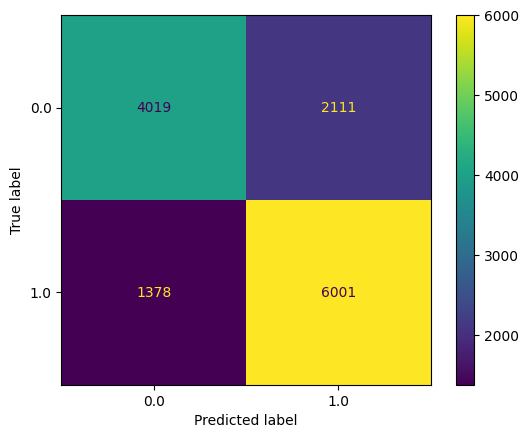

In [23]:
clf.fit(df.drop('class', axis='columns'), df['class'])
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

print(f"Our classifier has an accuracy of {accuracy_score(y_test, y_pred):0.2f}")
plt.show()